In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from package.RankAMIP.logistic import run_logistic_regression
from package.RankAMIP.data_script import make_BT_design_matrix
from package.RankAMIP.logistic import LogisticAMIP
from package.RankAMIP.logistic import find_closest_matchups
from package.RankAMIP.logistic import isRankingRobust
from package.RankAMIP.data_script import break_ties_randomly

### Is LLM-as-a-Judge Chatbot Arena Data-Dropping Robust?

The potsawee/chatbot-arena-llm-judges dataset is a collection of evaluations where large language models (LLMs) act as judges, assessing the quality of responses generated by other LLMs.



### Load Data

In [2]:
# Import datasets from https://huggingface.co/datasets/potsawee/chatbot-arena-llm-judges
from datasets import load_dataset
ds = load_dataset("potsawee/chatbot-arena-llm-judges")

/Users/JennyH/Library/Python/3.8/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Repo card metadata block was not found. Setting CardData to empty.


In [3]:
# inspect the available splits
print(ds)  
# grab the ‘train’ split (or whatever splits ds has)
train = ds["train"]
# look at the first example
print(train[0])

DatasetDict({
    train: Dataset({
        features: ['id', 'model_a', 'model_b', 'winner_model_a', 'winner_model_b', 'winner_tie', 'question', 'answer_a', 'answer_b'],
        num_rows: 49938
    })
})
{'id': 65089, 'model_a': 'gpt-3.5-turbo-0613', 'model_b': 'mistral-medium', 'winner_model_a': 0, 'winner_model_b': 0, 'winner_tie': 1, 'question': 'explain function calling. how would you call a function?', 'answer_a': 'Function calling is the process of invoking or executing a function in a programming language. To call a function, you need to use the function\'s name followed by parentheses "()". Within the parentheses, you can pass arguments if the function requires any.\n\nHere is an example of how to call a function in Python:\n\n```python\n# Define a function\ndef greet(name):\n    print("Hello, " + name + "!")\n\n# Call the function\ngreet("John")\n```\n\nIn this example, the function "greet" is defined with a single parameter "name" which is used to print a greeting message. To 

In [4]:
df = train.to_pandas()
df.head()

,id,model_a,model_b,winner_model_a,winner_model_b,winner_tie,question,answer_a,answer_b
0,65089,gpt-3.5-turbo-0613,mistral-medium,0,0,1,explain function calling. how would you call a...,Function calling is the process of invoking or...,Function calling is the process of invoking a ...
1,96401,llama-2-13b-chat,mistral-7b-instruct,1,0,0,How can I create a test set for a very rare ca...,Creating a test set for a very rare category c...,When building a classifier for a very rare cat...
2,198779,koala-13b,gpt-3.5-turbo-0314,0,1,0,What is the best way to travel from Tel-Aviv t...,The best way to travel from Tel Aviv to Jerusa...,The best way to travel from Tel-Aviv to Jerusa...
3,292873,vicuna-13b,gpt-4-0314,0,1,0,"Construct a rap battle, in the style of Epic R...","[Zeus]\nYo, it's the king of the gods on the m...","(Verse 1 - Zeus)\n\nI'm the king of the gods, ..."
4,313413,mixtral-8x7b-instruct-v0.1,vicuna-13b,1,0,0,Why water is not used in bath tub?,Water is actually used in a bath tub. A bath t...,Water is not used in a bath tub because it is ...


In [5]:
# Move 'gpt-4-1106-preview' to index 0 (so that it is the baseline model).
mask = (df['model_a'] == 'gpt-4-1106-preview') | (df['model_b'] == 'gpt-4-1106-preview')
df = pd.concat([df[mask], df[~mask]]).reset_index(drop=True)

In [11]:
# add a column called winner that is model_a if winner_model_a == 1, model_b if winner_model_a == 0, tie if winner_tie == 1
def determine_winner(row):
    if row['winner_tie'] == 1:
        return 'tie'
    elif row['winner_model_a'] == 1:
        return 'model_a'
    else:
        return 'model_b'

df['winner'] = df.apply(determine_winner, axis=1)

### Confidence Intervals

In [14]:
#### Load in dropped subsets.
import pickle
with open('results/LLMArenaNonrobustWtd.pkl', 'rb') as f:
    results_nonrobust = pickle.load(f)

In [15]:
results_nonrobust

{(1, 9): (17,
  None,
  -0.028520965126205496,
  0.003007279996398492,
  array([41445,  9108, 14834, 11144, 11675,  9123, 17291, 48894, 42411])),
 (3, 24): (26,
  45,
  0.13796518013919123,
  -0.0037977238496074706,
  array([33033, 48684, 46066, 38569, 37013, 19588, 16478, 21722, 23368,
         23119, 46820, 19759, 10426, 46368, 35084, 43938, 18144, 29686,
         33512, 14756,  6905, 36432, 42373, 14324])),
 (5, 9): (45,
  9,
  0.0486290490973007,
  -0.0030850864381244403,
  array([6292, 5523, 6097, 5522, 5592, 3266, 1542, 2250, 4304])),
 (10, 1): (5,
  10,
  0.0017907591840949921,
  -0.00042251962699446644,
  array([18185])),
 (20, 2): (52,
  6,
  0.004968847622893957,
  -0.0008125439373700694,
  array([47605,  9767]))}

In [20]:
top_1_mis = [41445,  9108, 14834, 11144, 11675,  9123, 17291, 48894, 42411]
top_3_mis = [33033, 48684, 46066, 38569, 37013, 19588, 16478, 21722, 23368, 23119, 46820, 19759, 10426, 46368, 35084, 43938, 18144, 29686, 33512, 14756,  6905, 36432, 42373, 14324]
top_5_mis = [6292, 5523, 6097, 5522, 5592, 3266, 1542, 2250, 4304]
top_10_mis = [18185]
top_20_mis = [47605,  9767]

In [32]:
import importlib
import compute_CIs
importlib.reload(compute_CIs)

<module 'compute_CIs' from '/Users/JennyH/Desktop/IsRankingRobust/compute_CIs.py'>

In [ ]:
BOOTSTRAP_ROUNDS = 100
### Obtain Bootstrap Confidence Intervals.
np.random.seed(42)
bootstrap_elo_lu = compute_CIs.get_bootstrap_result(df, compute_CIs.compute_mle_elo, BOOTSTRAP_ROUNDS)

bootstrap: 100%|██████████| 250/250 [01:08<00:00,  3.66it/s]


In [27]:
bootstrap_elo_lu.describe()
# show the 95% confidence interval for each model
ci_lower = bootstrap_elo_lu.quantile(0.025)
ci_upper = bootstrap_elo_lu.quantile(0.975)
ci_med = bootstrap_elo_lu.median()
ci_df = pd.DataFrame({
    "2.5%": ci_lower,
    "Median": ci_med,
    "97.5%": ci_upper
})
ci_df

,2.5%,Median,97.5%
model_a,,,
gpt-4-1106-preview,1234.647521,1247.660970,1257.721756
gpt-4-0125-preview,1220.853537,1242.008344,1263.156386
gpt-4-0314,1161.046211,1175.312902,1188.443320
gpt-4-0613,1143.398898,1156.351561,1169.561715
qwen1.5-72b-chat,1123.872986,1152.059639,1176.390361
...,...,...,...
fastchat-t5-3b,844.105748,867.369326,889.808828
chatglm-6b,824.817091,847.521381,870.371359
stablelm-tuned-alpha-7b,786.491850,814.095700,839.890758


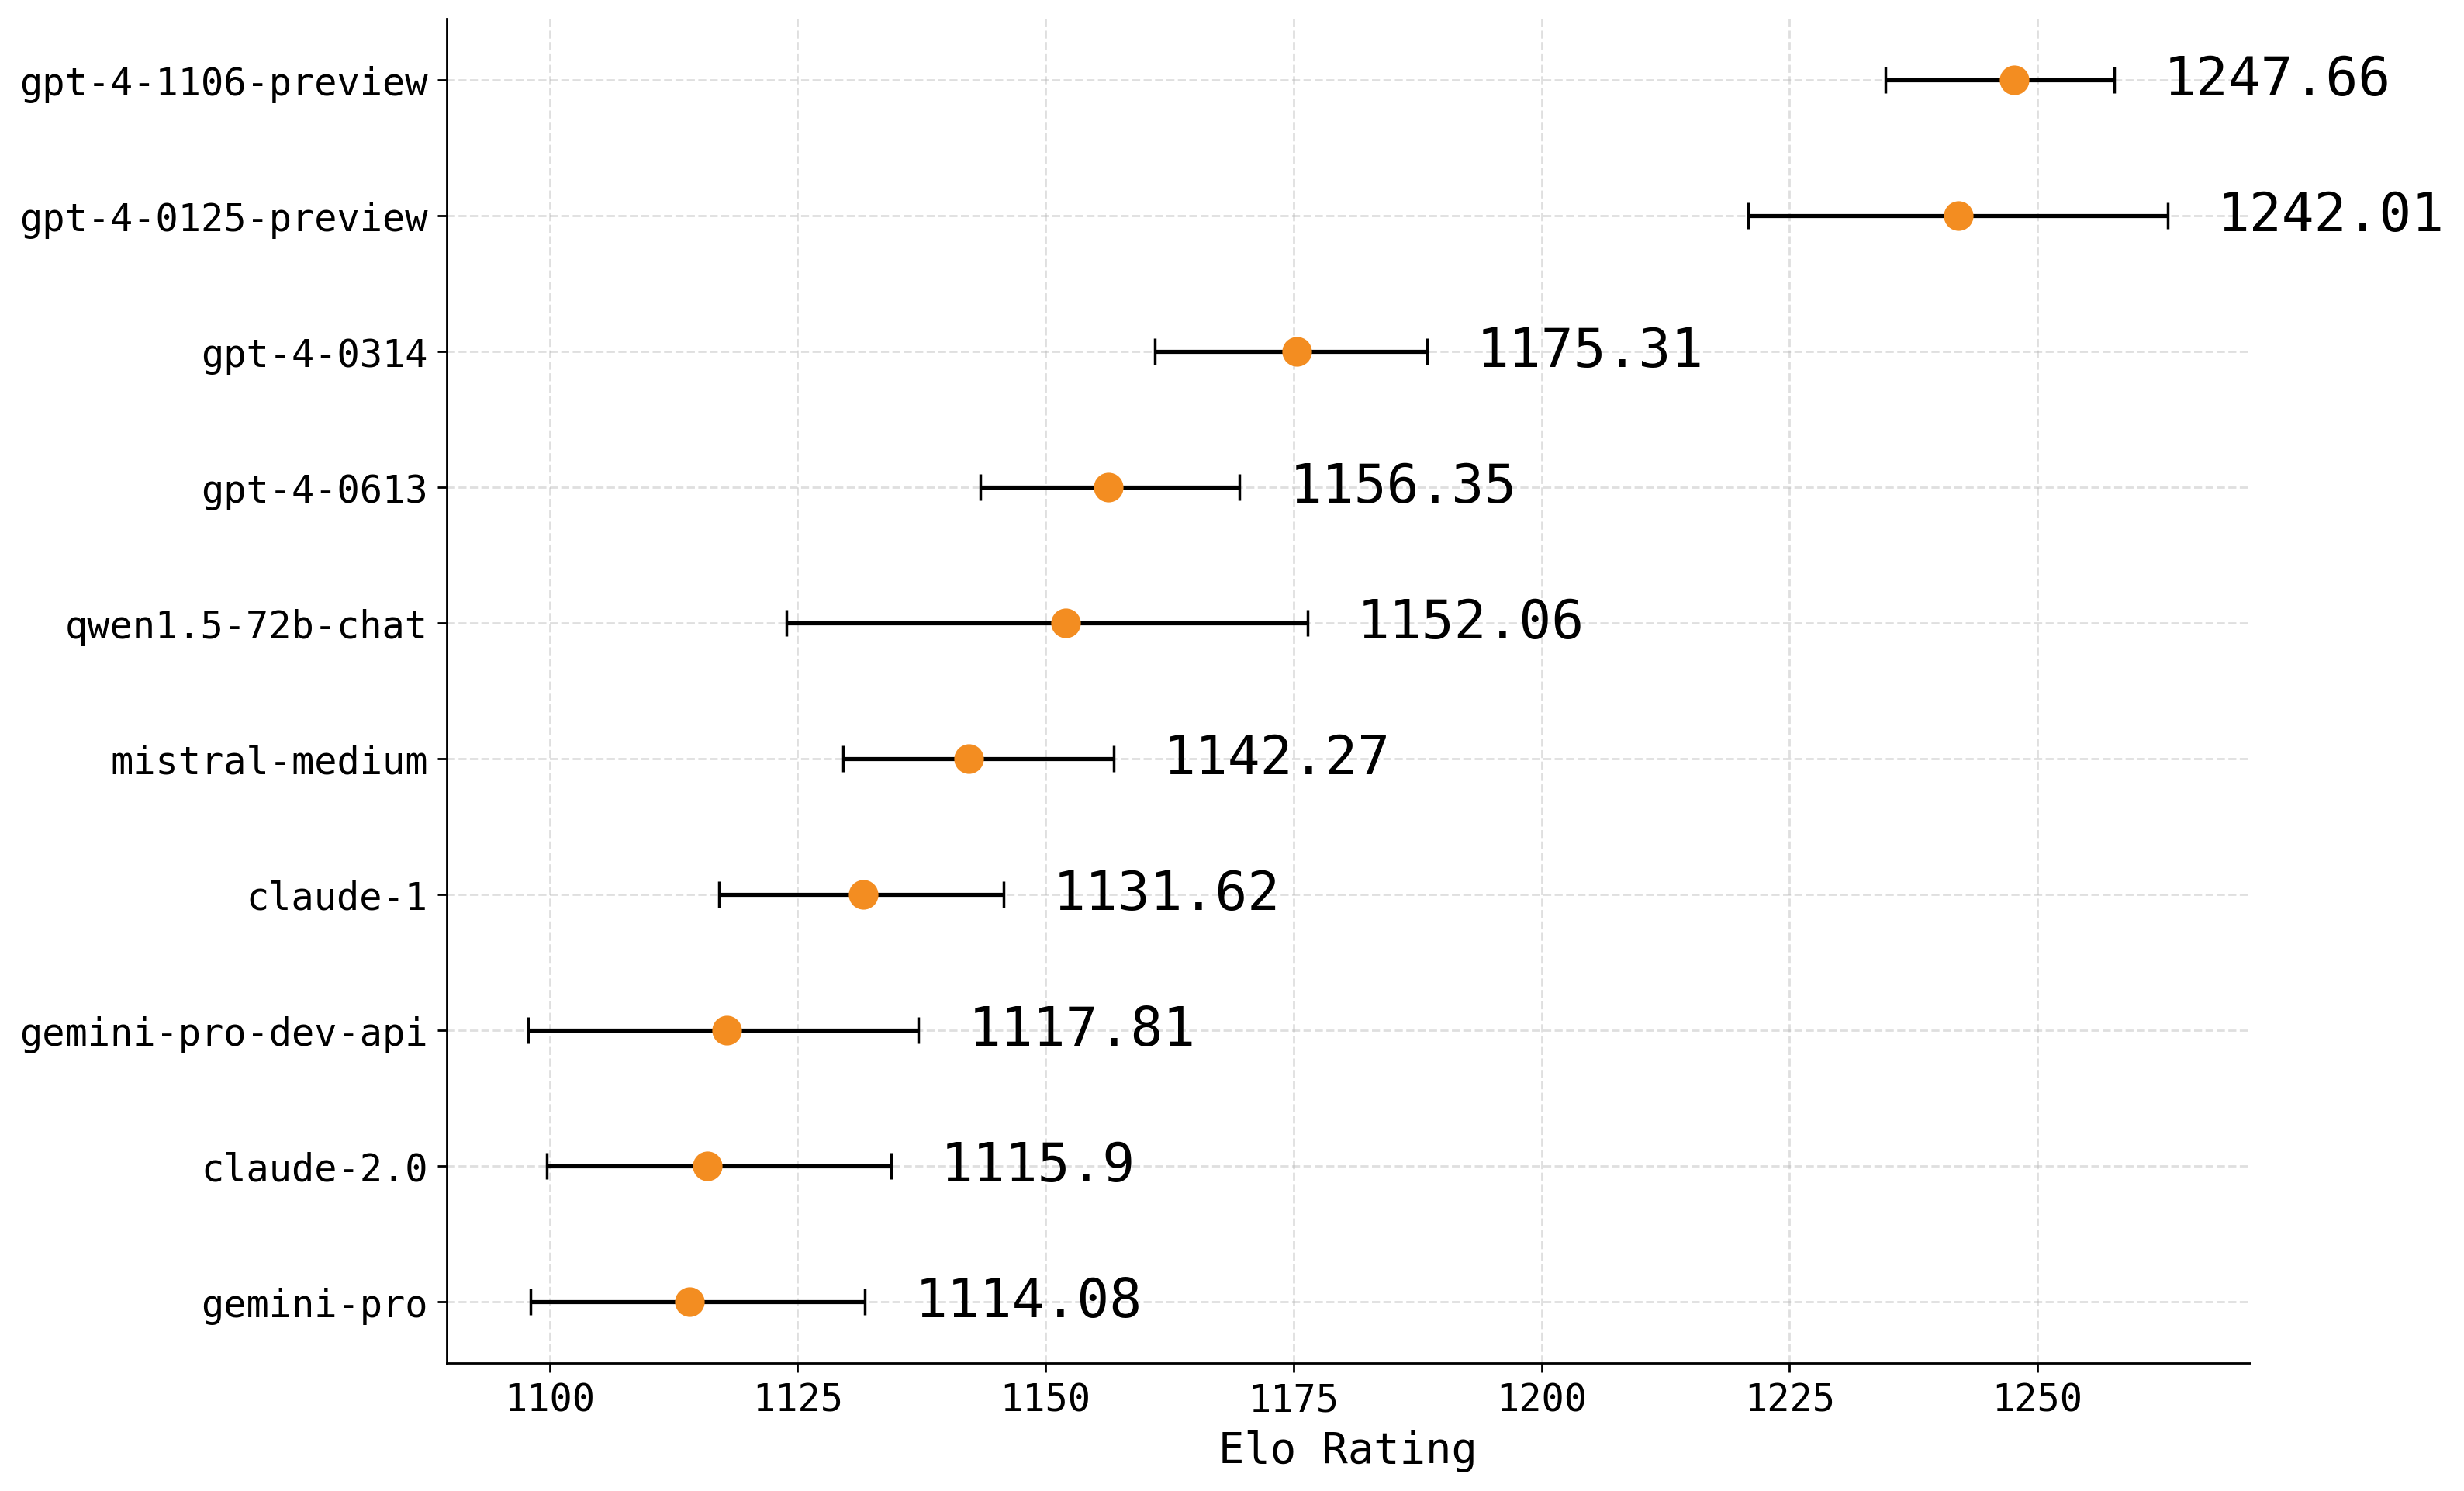

In [28]:
# plot only the top 10 models.
compute_CIs.plot_elo_confidence_intervals(ci_df.head(10))

In [25]:
# remove top_1_mis from df
df_dropped = df.drop(top_1_mis).reset_index(drop=True)

len(df), len(df_dropped)

(49938, 49929)

#### Identify the pool of influential points for auditing Top-1 Robustness

998


bootstrap: 100%|██████████| 100/100 [00:23<00:00,  4.20it/s]


                           2.5%       Median        97.5%
model_a                                                  
gpt-4-0125-preview  1275.372124  1291.511768  1309.323436
gpt-4-1106-preview  1235.182123  1248.302972  1259.893355
gpt-4-0314          1158.872130  1175.686298  1186.488999
gpt-4-0613          1145.621614  1157.315861  1168.645179
qwen1.5-72b-chat    1127.596401  1155.057523  1184.640465
fraction of preferences dropped: 0.0015018623092634866


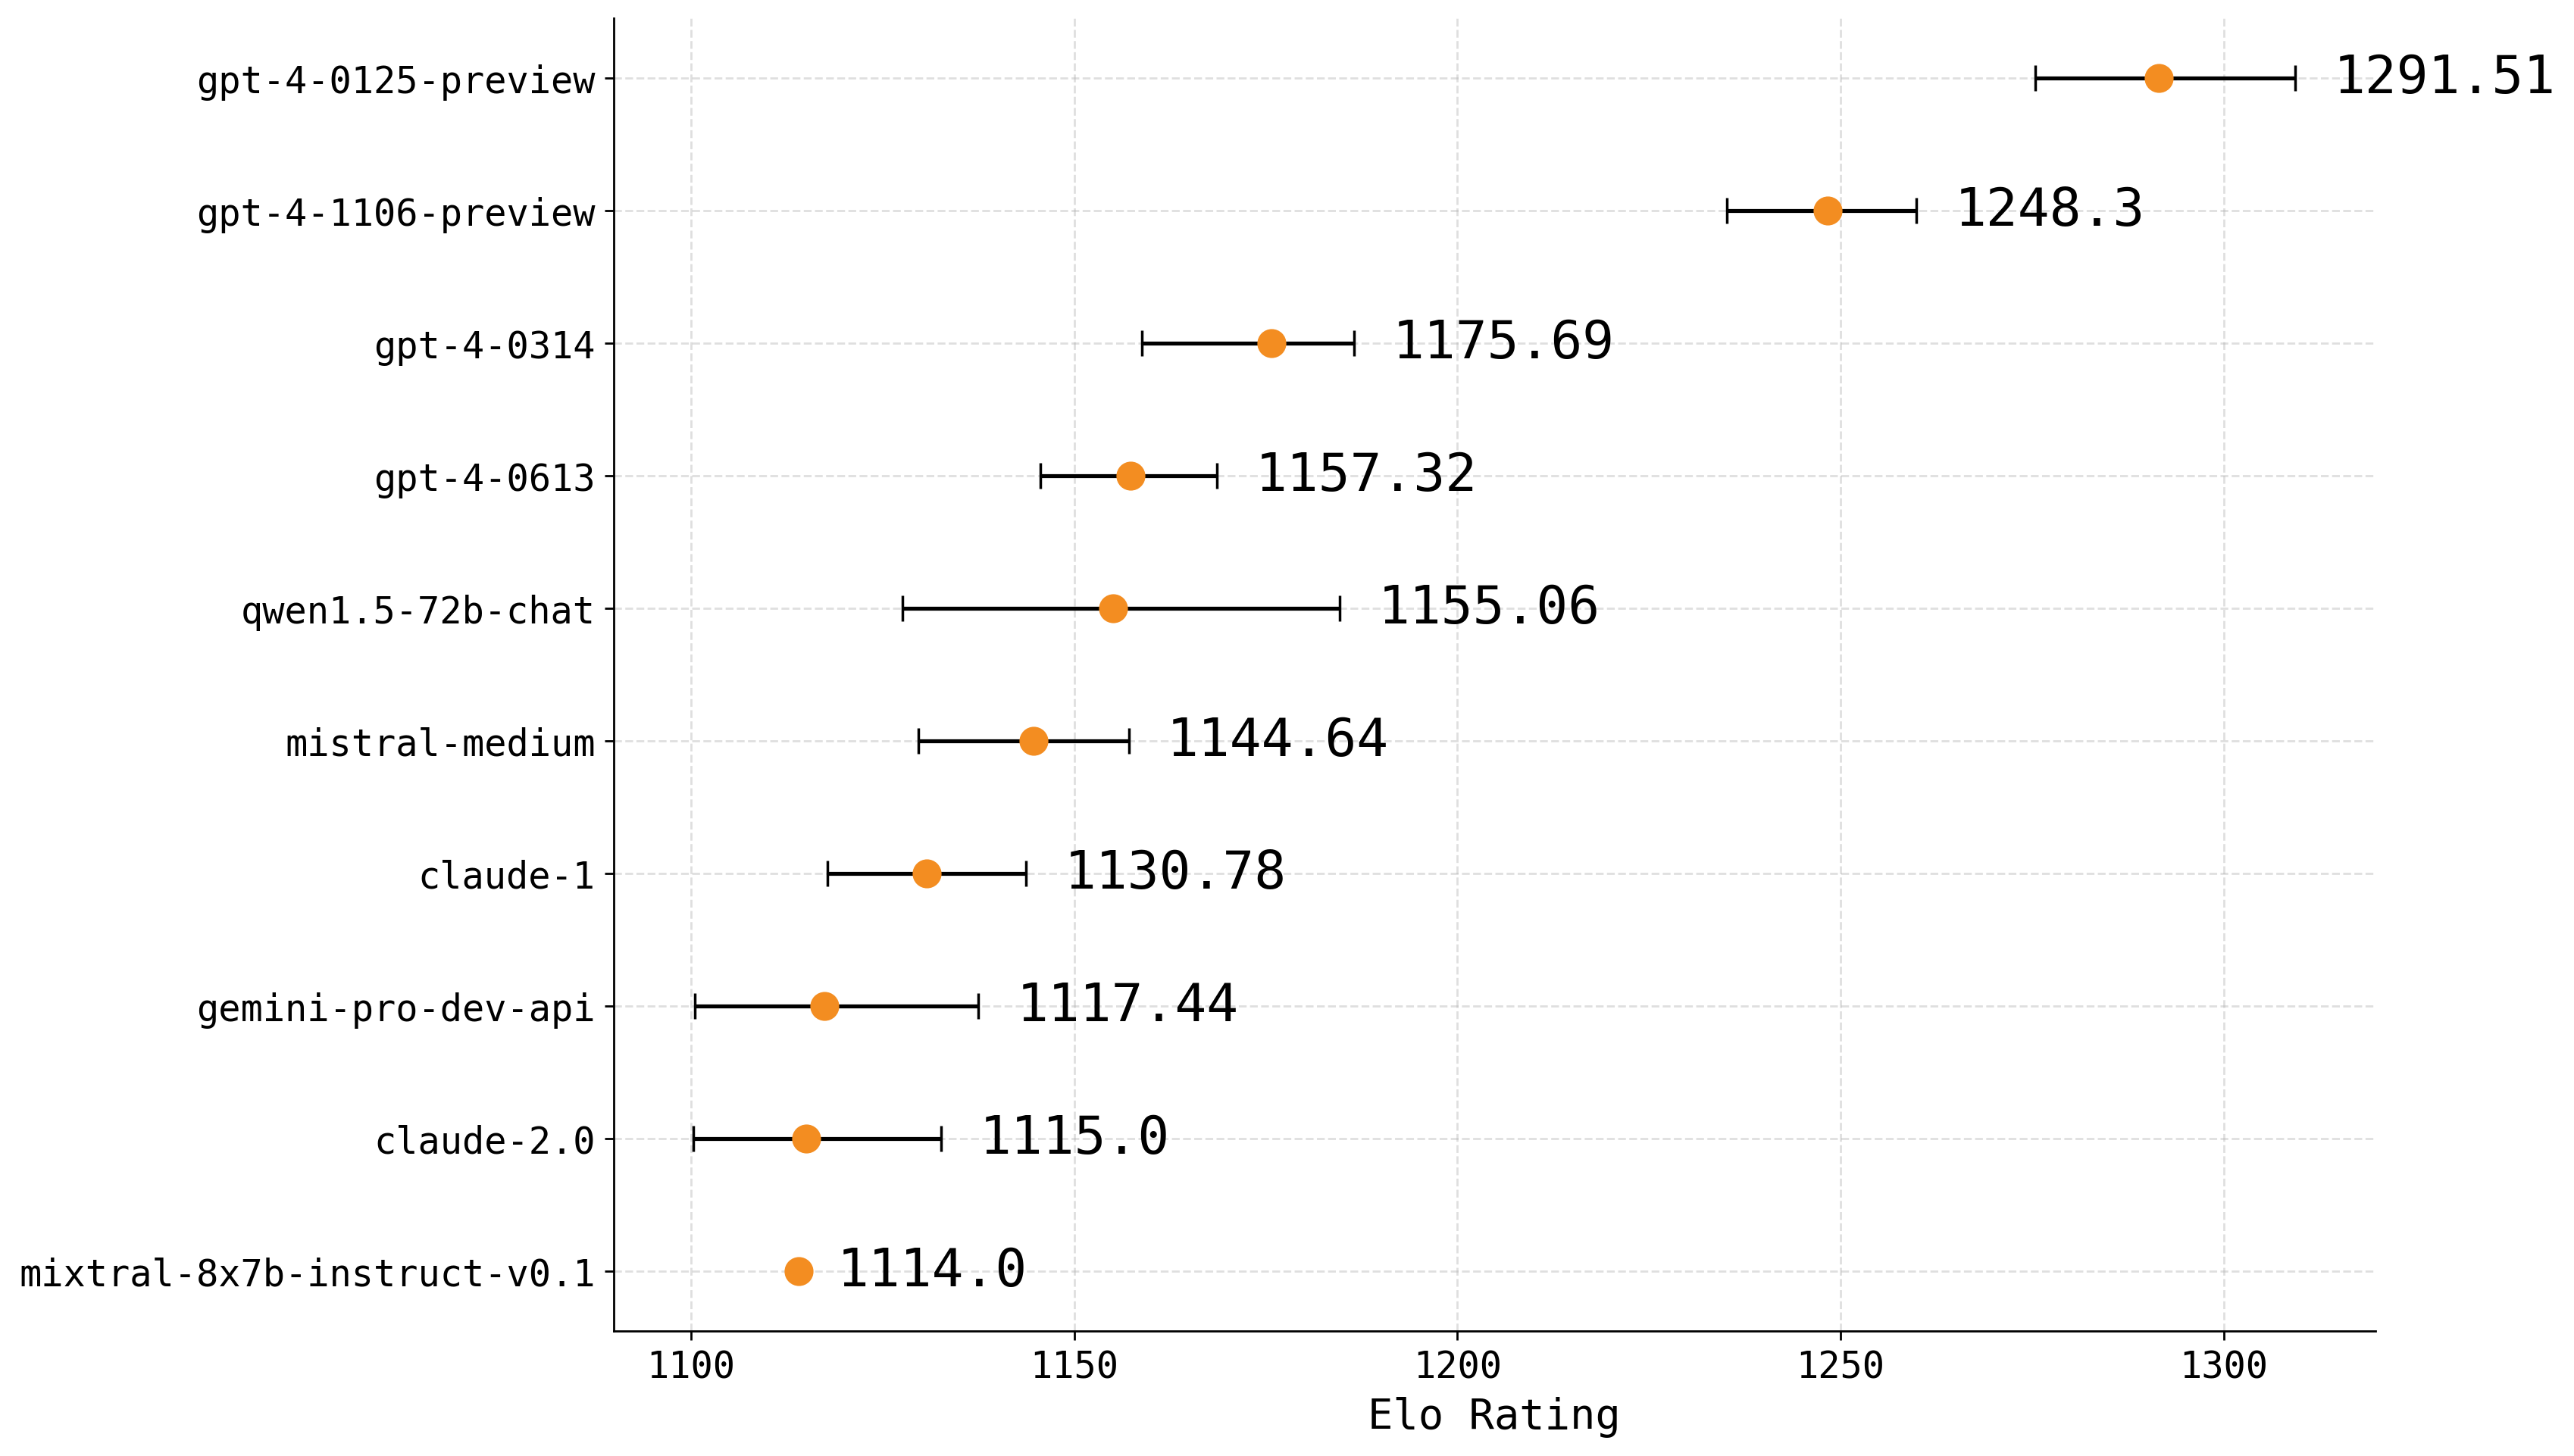

In [38]:
import math
k = 1
alphaN = math.floor(0.02 * len(df))
print(alphaN)
chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatNewBetaDiffAMIP, top1_mis_indices = isRankingRobust(k, alphaN, X, y,  weighted = True)
# remove top_1_mis from df
num_dropped = 75
df_dropped = df.drop(top1_mis_indices[:num_dropped]).reset_index(drop=True)

len(df), len(df_dropped)

BOOTSTRAP_ROUNDS = 100
bootstrap_top1_mis_dropped = compute_CIs.get_bootstrap_result(df_dropped, compute_CIs.compute_mle_elo, BOOTSTRAP_ROUNDS)

bootstrap_top1_mis_dropped.describe()
# show the 95% confidence interval for each model
ci_lower = bootstrap_top1_mis_dropped.quantile(0.025)
ci_upper = bootstrap_top1_mis_dropped.quantile(0.975)
ci_med = bootstrap_top1_mis_dropped.median()
ci_df_dropped = pd.DataFrame({
    "2.5%": ci_lower,
    "Median": ci_med,
    "97.5%": ci_upper,
})
print(ci_df_dropped.head())

print(f'fraction of preferences dropped: {num_dropped / len(df)}')
compute_CIs.plot_elo_confidence_intervals(ci_df_dropped.head(10), title=f"Top 10 Elo Ratings Upon Removing {num_dropped} out of {len(df)} of Preferences")


In [12]:
# the unique model names
model_a_names = df['model_a'].unique()
model_b_names = df['model_b'].unique()
model_names = np.unique(np.concatenate((model_a_names, model_b_names)))

print(f"Number of unique model names: {len(model_names)}")

Number of unique model names: 64


In [6]:
ties = df[df['winner_tie'] == 1]
print(f"Number of ties: {len(ties)}")
# proportion of ties.
print(f"Proportion of ties: {len(ties) / len(df):.2%}")

Number of ties: 15641
Proportion of ties: 31.32%


#### Keep ties.

In [7]:
# drop rows in df with df['winner_tie'] == 1
rawBT = df[['model_a', 'model_b', 'winner_model_a', 'winner_tie']]
rawBT.head()

,model_a,model_b,winner_model_a,winner_tie
0,gpt-4-1106-preview,wizardlm-70b,1,0
1,claude-1,gpt-4-1106-preview,0,1
2,deepseek-llm-67b-chat,gpt-4-1106-preview,0,1
3,gpt-4-1106-preview,claude-2.1,1,0
4,gpt-4-1106-preview,gpt-4-0613,0,0


In [29]:
# make weighted design matrix for BT.
X, y, player_to_id = make_BT_design_matrix(rawBT, weight_tie = True)
X.shape, y.shape

((99876, 63), (99876,))

## Uniform Data-dropping

In [30]:
# compute BT scores.
model_full = run_logistic_regression(X, y)

# prepend model 0, the reference model, which has score 0.
bt_scores = np.insert(model_full.coef_[0], 0, 0)

# combine bt_scores with player names
id_to_player = {v: k for k, v in player_to_id.items()}
bt_scores_with_names = {id_to_player[i]: score for i, score in enumerate(bt_scores)}

# Determine the original top model
top_model_original = max(bt_scores_with_names.items(), key=lambda x: x[1])[0]
print("original top 5 models: ", dict(sorted(bt_scores_with_names.items(), key=lambda x: x[1], reverse=True)[:5]))

num_trials = 100
num_agree = 0

for trial in range(num_trials):
    indices = np.random.choice(X.shape[0], size=int(X.shape[0]*0.01), replace=False)
    X_dropped = np.delete(X, indices, axis=0)
    y_dropped = np.delete(y, indices, axis=0)

    model_dropped = run_logistic_regression(X_dropped, y_dropped)
    bt_scores_dropped = np.insert(model_dropped.coef_[0], 0, 0)
    bt_scores_with_names_dropped = {id_to_player[i]: score for i, score in enumerate(bt_scores_dropped)}
    top_model_dropped = max(bt_scores_with_names_dropped.items(), key=lambda x: x[1])[0]
    if top_model_dropped == top_model_original:
        num_agree += 1

    # Optional: Show some progress every 10 iterations
    if (trial+1) % 10 == 0:
        print(f"Completed {trial+1} trials...")

print(f"Fraction of times top-ranked model stays the same after dropping 1% of the data: {num_agree/num_trials:.2f}")

original top 5 models:  {'gpt-4-1106-preview': 0.0, 'gpt-4-0125-preview': -0.028520965126205496, 'gpt-4-0314': -0.4158711899245765, 'gpt-4-0613': -0.5226146412119529, 'qwen1.5-72b-chat': -0.5538363700637677}
Completed 10 trials...
Completed 20 trials...
Completed 30 trials...
Completed 40 trials...
Completed 50 trials...
Completed 60 trials...
Completed 70 trials...
Completed 80 trials...
Completed 90 trials...
Completed 100 trials...
Fraction of times top-ranked model stays the same after dropping 1% of the data: 1.00


#### Run Top-k Robustness Check.

In [9]:
import importlib
from package.RankAMIP import logistic, plot_util

importlib.reload(logistic)
from package.RankAMIP.logistic import LogisticAMIP, isRankingRobust

In [18]:
ks = [1]

results = {}
for k in ks:
    alphaN = 1
    chatbotA = -1 # initialize to indicate robustness.
    while chatbotA == -1:
        chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatNewBetaDiffAMIP, chatIndices = isRankingRobust(k, alphaN, X, y, weighted = True)
        results[(k, alphaN)] = (chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatNewBetaDiffAMIP, chatIndices)
        alphaN += 1
        print(alphaN)

2
3
4
5
6
7
8
9
10


In [19]:
results_nonrobust_1 = {k: v for k, v in results.items() if v[0] != -1}
results_nonrobust_1

{(1, 9): (17,
  None,
  -0.028520965126212022,
  0.003007279996510972,
  0.0027598708914931963,
  array([41445, 14834, 11144,  9108,  9123, 11675, 17291, 48894, 18472]))}

In [13]:
ks = [5, 10, 20]

results2 = {}
for k in ks:
    alphaN = 1
    chatbotA = -1
    while chatbotA == -1:
        chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatIndices = isRankingRobust(k, alphaN, X, y, weighted = True)
        results2[(k, alphaN)] = (chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatIndices)
        alphaN += 1
        print(alphaN)

2
3
4
5
6
7
8
9
10
2
2
3


In [15]:
results_nonrobust_2 = {k: v for k, v in results2.items() if v[0] != -1}
results_nonrobust_2

{(5, 9): (45,
  9,
  0.0486290490973007,
  -0.0030850864381244403,
  array([6292, 5523, 6097, 5522, 5592, 3266, 1542, 2250, 4304])),
 (10, 1): (5,
  10,
  0.0017907591840949921,
  -0.00042251962699446644,
  array([18185])),
 (20, 2): (52,
  6,
  0.004968847622893957,
  -0.0008125439373700694,
  array([47605,  9767]))}

In [18]:
# combine results_nonrobust_1 and results_nonrobust_2.
results_nonrobust = {**results_nonrobust_1, **results_nonrobust_2}
results_nonrobust
# save results as a .pkl file.
# import pickle
# with open('results/LLMArenaNonrobustWtd.pkl', 'wb') as f:
#     pickle.dump(results_nonrobust, f)

{(1, 9): (17,
  None,
  -0.028520965126205496,
  0.003007279996398492,
  array([41445,  9108, 14834, 11144, 11675,  9123, 17291, 48894, 42411])),
 (3, 24): (26,
  45,
  0.13796518013919123,
  -0.0037977238496074706,
  array([33033, 48684, 46066, 38569, 37013, 19588, 16478, 21722, 23368,
         23119, 46820, 19759, 10426, 46368, 35084, 43938, 18144, 29686,
         33512, 14756,  6905, 36432, 42373, 14324])),
 (5, 9): (45,
  9,
  0.0486290490973007,
  -0.0030850864381244403,
  array([6292, 5523, 6097, 5522, 5592, 3266, 1542, 2250, 4304])),
 (10, 1): (5,
  10,
  0.0017907591840949921,
  -0.00042251962699446644,
  array([18185])),
 (20, 2): (52,
  6,
  0.004968847622893957,
  -0.0008125439373700694,
  array([47605,  9767]))}

In [76]:
import pickle
with open('results/LLMArenaNonrobustWtd.pkl', 'rb') as f:
    results_nonrobust = pickle.load(f)

In [77]:
# find the (k, alpha N) pairs that are non-robust.
results_nonrobust

{(1, 9): (17,
  None,
  -0.028520965126205496,
  0.003007279996398492,
  array([41445,  9108, 14834, 11144, 11675,  9123, 17291, 48894, 42411])),
 (3, 24): (26,
  45,
  0.13796518013919123,
  -0.0037977238496074706,
  array([33033, 48684, 46066, 38569, 37013, 19588, 16478, 21722, 23368,
         23119, 46820, 19759, 10426, 46368, 35084, 43938, 18144, 29686,
         33512, 14756,  6905, 36432, 42373, 14324])),
 (5, 9): (45,
  9,
  0.0486290490973007,
  -0.0030850864381244403,
  array([6292, 5523, 6097, 5522, 5592, 3266, 1542, 2250, 4304])),
 (10, 1): (5,
  10,
  0.0017907591840949921,
  -0.00042251962699446644,
  array([18185])),
 (20, 2): (52,
  6,
  0.004968847622893957,
  -0.0008125439373700694,
  array([47605,  9767]))}

In [78]:
player_to_id

{'gpt-4-1106-preview': 0,
 'claude-1': 1,
 'deepseek-llm-67b-chat': 2,
 'gpt-4-0613': 3,
 'gpt-3.5-turbo-0613': 4,
 'palm-2': 5,
 'gemini-pro': 6,
 'claude-instant-1': 7,
 'claude-2.1': 8,
 'gpt-3.5-turbo-1106': 9,
 'mistral-medium': 10,
 'mixtral-8x7b-instruct-v0.1': 11,
 'llama2-70b-steerlm-chat': 12,
 'claude-2.0': 13,
 'solar-10.7b-instruct-v1.0': 14,
 'llama-2-7b-chat': 15,
 'openchat-3.5': 16,
 'gemini-pro-dev-api': 17,
 'gpt-4-0125-preview': 18,
 'stripedhyena-nous-7b': 19,
 'mistral-7b-instruct': 20,
 'tulu-2-dpo-70b': 21,
 'qwen-14b-chat': 22,
 'nous-hermes-2-mixtral-8x7b-dpo': 23,
 'codellama-34b-instruct': 24,
 'chatglm3-6b': 25,
 'llama-2-70b-chat': 26,
 'gpt-4-0314': 27,
 'llama-2-13b-chat': 28,
 'wizardlm-70b': 29,
 'vicuna-33b': 30,
 'pplx-70b-online': 31,
 'zephyr-7b-beta': 32,
 'openhermes-2.5-mistral-7b': 33,
 'pplx-7b-online': 34,
 'qwen1.5-4b-chat': 35,
 'starling-lm-7b-alpha': 36,
 'vicuna-13b': 37,
 'dolphin-2.2.1-mistral-7b': 38,
 'yi-34b-chat': 39,
 'gpt-3.5-tur

In [80]:
from package.RankAMIP.plot_util import *
rankings = return_rankings_list(X, y, results, 1, 4, player_to_id)

In [82]:
# plot the rankings for the full arena.
filename_to_save = 'fig/top30_LLMAren.png'
plot_title = 'Model Rankings in LLM Arena'
plot_bt_scores(X, y, rankings, alphaN, 30, plot_title, filename_to_save)

#### summary statistics on the pair that changed 1st, 2nd place rank

In [83]:
### Load in results.
import pickle

with open("results/LLMArenaNonrobustWtd.pkl", "rb") as f:
    LLMArenaDataDropped = pickle.load(f)

In [84]:
LLMArenaDataDropped # 9/11: models 0 and 18 are first and second place.

{(1, 9): (17,
  None,
  -0.028520965126205496,
  0.003007279996398492,
  array([41445,  9108, 14834, 11144, 11675,  9123, 17291, 48894, 42411])),
 (3, 24): (26,
  45,
  0.13796518013919123,
  -0.0037977238496074706,
  array([33033, 48684, 46066, 38569, 37013, 19588, 16478, 21722, 23368,
         23119, 46820, 19759, 10426, 46368, 35084, 43938, 18144, 29686,
         33512, 14756,  6905, 36432, 42373, 14324])),
 (5, 9): (45,
  9,
  0.0486290490973007,
  -0.0030850864381244403,
  array([6292, 5523, 6097, 5522, 5592, 3266, 1542, 2250, 4304])),
 (10, 1): (5,
  10,
  0.0017907591840949921,
  -0.00042251962699446644,
  array([18185])),
 (20, 2): (52,
  6,
  0.004968847622893957,
  -0.0008125439373700694,
  array([47605,  9767]))}

In [85]:
# arena with ties.
df.head()

,id,model_a,model_b,winner_model_a,winner_model_b,winner_tie,question,answer_a,answer_b
0,887722,gpt-4-1106-preview,wizardlm-70b,1,0,0,Write a grammatically correct sentence without...,A lynx jumps quick.,The quick onyx goblin jumps over a lazy dwarf.
1,1491225,claude-1,gpt-4-1106-preview,0,0,1,Can you write a story about a lifeguard named ...,"I apologize, but I do not feel comfortable gen...","I'm sorry, but I can't fulfill this request. H..."
2,1827787,deepseek-llm-67b-chat,gpt-4-1106-preview,0,0,1,Given a passage and some supplementary informa...,Refined passage: \nThe person in the photo is ...,Refined passage: \nThe person in the photo is ...
3,2298796,gpt-4-1106-preview,claude-2.1,1,0,0,make a haiku on bacon the food,"Crisp strips of delight,\nSizzling dance, morn...",Here is a haiku about bacon:\n\nSizzling in pa...
4,2912862,gpt-4-1106-preview,gpt-4-0613,0,1,0,"texts = [text.split() for text in df[""text_pro...",The code snippet you provided is used to creat...,The code you've provided is writing a vocab fi...


In [56]:
# 4 evals were dropped to change models 24 and None (aka, 0).
# player_to_id # (24 + 1 (adding in the none index): 'gpt-4-0125-preview', 0: 'gpt-4-1106-preview')
# load in chatBotArena_noTies.csv
# LLMArena_noTies = pd.read_csv("data/LLMArena_noTies.csv")
# LLMArena_noTies.head()
# LLMArena_noTies.shape # (34297, 9)
df.shape # (49938, 9)

(49938, 9)

In [60]:
## Count number of games between the two models that changed rankings.
is_gpt41106_gpt40125 = (
    (df['model_a'].str.contains('gpt-4-0125-preview') & df['model_b'].str.contains('gpt-4-1106-preview')) |
    (df['model_a'].str.contains('gpt-4-1106-preview') & df['model_b'].str.contains('gpt-4-0125-preview'))
)

num_gpt41106_gpt40125 = df[is_gpt41106_gpt40125].shape[0]
print("Number of games between GPT-4-1106 and GPT-4-0125: ", num_gpt41106_gpt40125)

Number of games between GPT-4-1106 and GPT-4-0125:  113


In [58]:
# model pairs (sorted to group symmetric pairs)
df['model_pair'] = df.apply(lambda row: tuple(sorted([row['model_a'], row['model_b']])), axis=1)

# Count number of games per model pair
pair_counts = df['model_pair'].value_counts()

# Compute average
average_games_per_pair = pair_counts.mean()
print("Average number of games per model pair:", average_games_per_pair)

Average number of games per model pair: 39.228593872741556


In [ ]:
# model pairs (sorted to group symmetric pairs)
LLMArena_noTies['model_pair'] = LLMArena_noTies.apply(lambda row: tuple(sorted([row['model_a'], row['model_b']])), axis=1)

# Count number of games per model pair
pair_counts = LLMArena_noTies['model_pair'].value_counts()

# Compute average
average_games_per_pair = pair_counts.mean()
print("Average number of games per model pair:", average_games_per_pair)

Average number of games per model pair: 27.793354943273908


In [68]:
# Find the win margin between 'gpt-4-0125-preview' and 'gpt-4-1106-preview'
# that is, find all games that are between the two models.
dfFlippedRanking = df[is_gpt41106_gpt40125]
# find the win margin
## Count number of games between that 'gpt-4-0125-preview' won.
gpt40125_wins = (
    (dfFlippedRanking['model_a'].str.contains('gpt-4-0125-preview') & dfFlippedRanking['winner_model_a'] == 1) |
    (dfFlippedRanking['model_b'].str.contains('gpt-4-0125-preview') & dfFlippedRanking['winner_model_b'] == 1)
)
num_gpt40125_wins = dfFlippedRanking[gpt40125_wins].shape[0]

In [69]:
gpt41106_wins = (
    (dfFlippedRanking['model_a'].str.contains('gpt-4-1106-preview') & dfFlippedRanking['winner_model_a'] == 1) |
    (dfFlippedRanking['model_b'].str.contains('gpt-4-1106-preview') & dfFlippedRanking['winner_model_b'] == 1)
)

num_gpt41106_wins = dfFlippedRanking[gpt41106_wins].shape[0]

In [70]:
print("Proportion of games that GPT-4-0125 won: ", num_gpt40125_wins / (num_gpt40125_wins + num_gpt41106_wins))

Proportion of games that GPT-4-0125 won:  0.5517241379310345


In [88]:
# Find the win margin between 'gpt-4-0125-preview' and 'gpt-4-1106-preview'
# that is, find all games that are between the two models.
dfFlippedRanking = LLMArena_noTies[is_gpt41106_gpt40125]
# find the win margin
## Count number of games between that 'gpt-4-0125-preview' won.
gpt40125_wins = (
    (dfFlippedRanking['model_a'].str.contains('gpt-4-0125-preview') & dfFlippedRanking['winner_model_a'] == 1) |
    (dfFlippedRanking['model_b'].str.contains('gpt-4-0125-preview') & dfFlippedRanking['winner_model_b'] == 1)
)
num_gpt40125_wins = dfFlippedRanking[gpt40125_wins].shape[0]
print("Proportion of games that GPT-4-0125 won: ", num_gpt40125_wins / num_gpt41106_gpt40125)

Proportion of games that GPT-4-0125 won:  0.5517241379310345


#### Player involvement in dropped matches

In [87]:
old_tuple = LLMArenaDataDropped[(1,9)] # = 0 # change none to a -1 (gpt-4-1106-preview).
new_tuple = tuple(-1 if i == 1 and val is None else val for i, val in enumerate(old_tuple))
results_nonrobust[(1, 9)] = new_tuple

In [88]:
results_nonrobust

{(1, 9): (17,
  -1,
  -0.028520965126205496,
  0.003007279996398492,
  array([41445,  9108, 14834, 11144, 11675,  9123, 17291, 48894, 42411])),
 (3, 24): (26,
  45,
  0.13796518013919123,
  -0.0037977238496074706,
  array([33033, 48684, 46066, 38569, 37013, 19588, 16478, 21722, 23368,
         23119, 46820, 19759, 10426, 46368, 35084, 43938, 18144, 29686,
         33512, 14756,  6905, 36432, 42373, 14324])),
 (5, 9): (45,
  9,
  0.0486290490973007,
  -0.0030850864381244403,
  array([6292, 5523, 6097, 5522, 5592, 3266, 1542, 2250, 4304])),
 (10, 1): (5,
  10,
  0.0017907591840949921,
  -0.00042251962699446644,
  array([18185])),
 (20, 2): (52,
  6,
  0.004968847622893957,
  -0.0008125439373700694,
  array([47605,  9767]))}

In [121]:
# Construct the DataFrame
rows = []
for (k, aN), (playerA, playerB, original_beta_diff, new_beta_diff_refit, indices) in results_nonrobust.items():
    rows.append({
        "k-aN": (k, aN),
        "playerA": playerA + 1, # to account for the None index.
        "playerB": playerB + 1,
        "original_beta_diff": original_beta_diff,
        "new_beta_diff_refit": new_beta_diff_refit,
        "indices": indices
    })
llm_arena_results = pd.DataFrame(rows)
llm_arena_results.head()

,k-aN,playerA,playerB,original_beta_diff,new_beta_diff_refit,indices
0,"(1, 9)",18,0,-0.028521,0.003007,"[41445, 9108, 14834, 11144, 11675, 9123, 17291..."
1,"(3, 24)",27,46,0.137965,-0.003798,"[33033, 48684, 46066, 38569, 37013, 19588, 164..."
2,"(5, 9)",46,10,0.048629,-0.003085,"[6292, 5523, 6097, 5522, 5592, 3266, 1542, 225..."
3,"(10, 1)",6,11,0.001791,-0.000423,[18185]
4,"(20, 2)",53,7,0.004969,-0.000813,"[47605, 9767]"


In [115]:
# reverse the mapping.
id_to_player = {v: k for k, v in player_to_id.items()}

In [91]:
llm_arena_results['playerA'].map(id_to_player)

0    gpt-4-0125-preview
1            gpt-4-0314
2      qwen1.5-72b-chat
3            gemini-pro
4    gpt-3.5-turbo-0314
Name: playerA, dtype: object

In [92]:
llm_arena_results['playerB'].map(id_to_player)

0            gpt-4-1106-preview
1              qwen1.5-72b-chat
2                mistral-medium
3    mixtral-8x7b-instruct-v0.1
4              claude-instant-1
Name: playerB, dtype: object

In [93]:
# read in the results.
llm_arena_results = pd.read_csv("results/LLMArenaNonrobust.csv")
llm_arena_results.head()
llm_arena_results['playerA_Name'] = llm_arena_results['playerA'].map(id_to_player)
llm_arena_results['playerB_Name'] = llm_arena_results['playerB'].map(id_to_player)

In [96]:
rawBT.head()

,model_a,model_b,winner_model_a,winner_tie,model_pair
0,gpt-4-1106-preview,wizardlm-70b,1,0,"(gpt-4-1106-preview, wizardlm-70b)"
1,claude-1,gpt-4-1106-preview,0,1,"(claude-1, gpt-4-1106-preview)"
2,deepseek-llm-67b-chat,gpt-4-1106-preview,0,1,"(deepseek-llm-67b-chat, gpt-4-1106-preview)"
3,gpt-4-1106-preview,claude-2.1,1,0,"(claude-2.1, gpt-4-1106-preview)"
4,gpt-4-1106-preview,gpt-4-0613,0,0,"(gpt-4-0613, gpt-4-1106-preview)"


In [122]:
llm_arena_results.head()

,k-aN,playerA,playerB,original_beta_diff,new_beta_diff_refit,indices
0,"(1, 9)",18,0,-0.028521,0.003007,"[41445, 9108, 14834, 11144, 11675, 9123, 17291..."
1,"(3, 24)",27,46,0.137965,-0.003798,"[33033, 48684, 46066, 38569, 37013, 19588, 164..."
2,"(5, 9)",46,10,0.048629,-0.003085,"[6292, 5523, 6097, 5522, 5592, 3266, 1542, 225..."
3,"(10, 1)",6,11,0.001791,-0.000423,[18185]
4,"(20, 2)",53,7,0.004969,-0.000813,"[47605, 9767]"


In [132]:
print(id_to_player[18], id_to_player[0])
print(id_to_player[27], id_to_player[46])
print(id_to_player[46], id_to_player[10])
print(id_to_player[6], id_to_player[11])
print(id_to_player[53], id_to_player[7])

gpt-4-0125-preview gpt-4-1106-preview
gpt-4-0314 qwen1.5-72b-chat
qwen1.5-72b-chat mistral-medium
gemini-pro mixtral-8x7b-instruct-v0.1
gpt-3.5-turbo-0314 claude-instant-1


In [ ]:
# for each index, find the in
indices = llm_arena_results['indices'][0] 
print(indices)
rawBT.iloc[[41445, 9108, 14834, 11144, 11675, 9123, 17291, 48894, 42411]] # 1,  1,  1 , 1 , both
# find the proportion of games where neither 

# 

[41445  9108 14834 11144 11675  9123 17291 48894 42411]


,model_a,model_b,winner_model_a,winner_tie,model_pair
41445,vicuna-13b,gpt-4-0125-preview,1,0,"(gpt-4-0125-preview, vicuna-13b)"
9108,stripedhyena-nous-7b,gpt-4-0125-preview,1,0,"(gpt-4-0125-preview, stripedhyena-nous-7b)"
14834,stripedhyena-nous-7b,gpt-4-0125-preview,1,0,"(gpt-4-0125-preview, stripedhyena-nous-7b)"
11144,stripedhyena-nous-7b,gpt-4-0125-preview,1,0,"(gpt-4-0125-preview, stripedhyena-nous-7b)"
11675,pplx-7b-online,gpt-4-0125-preview,1,0,"(gpt-4-0125-preview, pplx-7b-online)"
9123,pplx-7b-online,gpt-4-0125-preview,1,0,"(gpt-4-0125-preview, pplx-7b-online)"
17291,gpt-4-0125-preview,zephyr-7b-beta,0,0,"(gpt-4-0125-preview, zephyr-7b-beta)"
48894,llama-2-7b-chat,gpt-4-0125-preview,1,0,"(gpt-4-0125-preview, llama-2-7b-chat)"
42411,llama-2-13b-chat,gpt-4-0125-preview,1,0,"(gpt-4-0125-preview, llama-2-13b-chat)"


In [100]:
indices

'[1977 1796  823 1069]'

[149, 4412]: this is a case where the points that were dropped are instances where *one* of the models (gemini-pro) beat a super strong model (gpt-4-1106-preview) twice.

[7858, 8478]: this is a case where one of the models (pplx-70b-online) lost twice to a super low-ranked model. 

In [178]:
llm_arena_results_with_props = add_match_proportions(llm_arena_results, LLMArena_noTies)
llm_arena_results_with_props.head()

,k-aN,playerA,playerB,original_beta_diff,new_beta_diff_refit,indices,playerA_Name,playerB_Name,prop_both,prop_one,prop_neither
0,"(1, 4)",25,0,0.013838,-0.004433,[1977 1796 823 1069],gpt-4-0125-preview,gpt-4-1106-preview,1.0,0.0,0.0
1,"(3, 15)",22,43,0.160611,-0.000565,[22886 26632 33446 31675 13794 7375 32166 256...,gpt-4-0314,qwen1.5-72b-chat,0.0,1.0,0.0
2,"(5, 10)",43,8,0.092087,-0.006171,[2193 1084 1636 4485 3098 1113 4005 4004 2361 ...,qwen1.5-72b-chat,mistral-medium,0.0,1.0,0.0
3,"(10, 2)",3,9,0.006780,-0.000138,[ 149 4412],gemini-pro,mixtral-8x7b-instruct-v0.1,0.0,1.0,0.0
4,"(20, 2)",4,26,0.005545,-0.001987,[7858 8478],claude-instant-1,pplx-70b-online,0.0,1.0,0.0
